In [1]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 66.0 MB/s eta 0:00:00


In [2]:
import os
import yaml
import shutil
import random
import kagglehub
from ultralytics import YOLO
import xml.etree.ElementTree as ET
import pandas as pd
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
downloaded_data_dir = kagglehub.dataset_download("andrewmvd/car-plate-detection")
print(f"Downloaded Kaggle dataset to {downloaded_data_dir}")

downloaded_images_dir = os.path.join(downloaded_data_dir, "images")
downloaded_annotations_dir = os.path.join(downloaded_data_dir, "annotations")

working_dir = "/kaggle/working"

images_dir = os.path.join(working_dir, "images")
train_images_dir = os.path.join(images_dir, "train")
val_images_dir = os.path.join(images_dir, "val")

labels_dir = os.path.join(working_dir, "labels")
train_labels_dir = os.path.join(labels_dir, "train")
val_labels_dir = os.path.join(labels_dir, "val")


100%|██████████| 203M/203M [00:13<00:00, 16.1MB/s] 

Extracting files...


Downloaded Kaggle dataset to /root/.cache/kagglehub/datasets/andrewmvd/car-plate-detection/versions/1


In [4]:
def convert_min_max_to_center_dims(width, height, xmin, xmax, ymin, ymax):
    x_center = ((xmin + xmax) / 2) / width
    y_center = ((ymin + ymax) / 2) / height
    w = (xmax - xmin) / width
    h = (ymax - ymin) / height
    return x_center, y_center, w, h

In [5]:
def prepare_yolo_dataset(train_ratio=0.75):
    if os.path.exists(working_dir):
        shutil.rmtree(working_dir)

    os.makedirs(train_images_dir)
    os.makedirs(val_images_dir)
    os.makedirs(train_labels_dir)
    os.makedirs(val_labels_dir)

    # Shuffle the image files
    image_files = [f for f in os.listdir(downloaded_images_dir) if f.endswith((".png",".jpg",".jpeg"))]
    random.shuffle(image_files)

    # Split the image files for training and validation
    split_index = int(len(image_files) * train_ratio)
    train_files = image_files[:split_index]
    val_files = image_files[split_index:]

    # -------- TRAIN --------
    for img in train_files:
        base = os.path.splitext(img)[0]
        xml_file = base + ".xml"

        original_image_path = os.path.join(downloaded_images_dir, img)
        train_image_path = os.path.join(train_images_dir, img)
        shutil.copy(original_image_path, train_image_path)

        original_xml_path = os.path.join(downloaded_annotations_dir, xml_file)
        label_path = os.path.join(train_labels_dir, base + ".txt")

        lines = []

        if os.path.exists(original_xml_path):
            tree = ET.parse(original_xml_path)
            root = tree.getroot()

            width = float(root.find("size/width").text)
            height = float(root.find("size/height").text)

            for obj in root.findall("object"):
                xmin = float(obj.find("bndbox/xmin").text)
                xmax = float(obj.find("bndbox/xmax").text)
                ymin = float(obj.find("bndbox/ymin").text)
                ymax = float(obj.find("bndbox/ymax").text)

                x_center, y_center, w, h = convert_min_max_to_center_dims(width, height, xmin, xmax, ymin, ymax)
                lines.append(f"0 {x_center} {y_center} {w} {h}")

        with open(label_path, "w") as f:
            f.write("\n".join(lines))

    # -------- VALIDATION --------
    for img in val_files:
        base = os.path.splitext(img)[0]
        xml_file = base + ".xml"

        original_image_path = os.path.join(downloaded_images_dir, img)
        val_image_path = os.path.join(val_images_dir, img)
        shutil.copy(original_image_path, val_image_path)

        original_xml_path = os.path.join(downloaded_annotations_dir, xml_file)
        label_path = os.path.join(val_labels_dir, base + ".txt")

        lines = []

        if os.path.exists(original_xml_path):
            tree = ET.parse(original_xml_path)
            root = tree.getroot()

            width = float(root.find("size/width").text)
            height = float(root.find("size/height").text)

            for obj in root.findall("object"):
                xmin = float(obj.find("bndbox/xmin").text)
                xmax = float(obj.find("bndbox/xmax").text)
                ymin = float(obj.find("bndbox/ymin").text)
                ymax = float(obj.find("bndbox/ymax").text)

                x_center, y_center, w, h = convert_min_max_to_center_dims(width, height, xmin, xmax, ymin, ymax)
                lines.append(f"0 {x_center} {y_center} {w} {h}")

        with open(label_path, "w") as f:
            f.write("\n".join(lines))

    print("Dataset prepared successfully.")
    print("Train images:", len(train_files))
    print("Validation images:", len(val_files))

In [6]:
def create_yolo_data_yaml(working_path):
    data = {
        "path": working_dir,
        "train": "images/train",
        "val": "images/val",
        "names": {
            0: "license"
        }
    }

    yaml_path = os.path.join(working_path, "data.yaml")

    with open(yaml_path, "w") as f:
        yaml.dump(data, f, sort_keys=False)

    print(f"YOLO config file created at: {yaml_path}")
    return yaml_path

In [7]:
prepare_yolo_dataset()

Dataset prepared successfully.
Train images: 324
Validation images: 109


In [8]:
create_yolo_data_yaml(working_dir)

YOLO config file created at: /kaggle/working/data.yaml


'/kaggle/working/data.yaml'

In [25]:
model = YOLO('yolov8s.yaml')
config_path = "/kaggle/working/data.yaml"

In [ ]:
model.train(data=config_path, epochs=400, batch=32, optimizer='Adam', lr0=0.001, patience=20)

Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=400, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=True, patience=20, perspective

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x782c5879d580>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

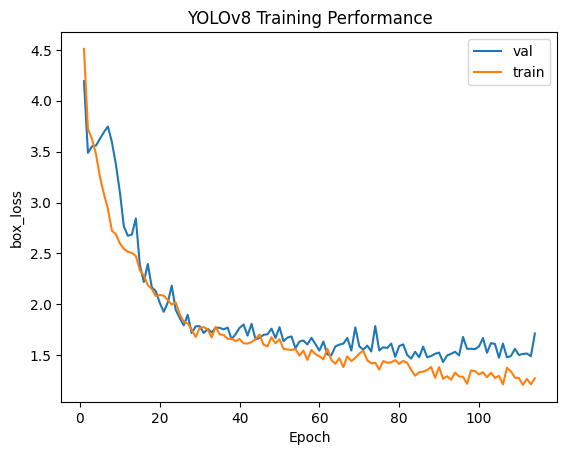

In [27]:
results = pd.read_csv("runs/detect/train4/results.csv")

plt.plot(results["epoch"], results["val/box_loss"], label='val')
plt.plot(results["epoch"], results["train/box_loss"], label='train')
plt.xlabel("Epoch")
plt.ylabel("box_loss")
plt.legend()
plt.title("YOLOv8 Training Performance")
plt.show()

In [ ]:
# new_model = YOLO('/content/runs/detect/train/weights/last.pt')
# new_model.train(data=config_path, epochs=400, batch=32, optimizer='Adam', lr0=0.001, patience=20)

Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=400, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/detect/train4/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x782cd01b2480>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 